# Why Language Models Hallucinate — Toy Implementation
### Paper: Kalai, Nachum, Vempala, Zhang (2025) · arXiv:2509.04664

---

## What this notebook teaches

The paper makes two claims:

1. **Pretraining causes hallucination** via a reduction to binary classification.  
   *Generative error rate ≥ 2 × IIV misclassification rate.*  
   A "singleton fact" (seen once in training) will almost certainly be hallucinated.

2. **Post-training preserves hallucination** because standard benchmarks award 0 for "IDK" —  
   so the rational strategy is always to guess.

We build toy simulations of both claims and watch them play out numerically.

## Cell 1 — Setup

In [1]:
import random
import math
import collections
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

random.seed(42)
print("All imports OK — running on CPU, stdlib only (random, math, collections, matplotlib)")

All imports OK — running on CPU, stdlib only (random, math, collections, matplotlib)


## Cell 2 — Problem Setup

The paper partitions all plausible text into **X = V ∪ E**:
- **V** = valid outputs (correct facts)
- **E** = errors (plausible falsehoods, e.g. "Einstein was born March 5")

A language model's **generative error rate** is `err = p̂(E)` — how much probability mass it assigns to errors.

### The Is-It-Valid (IIV) Binary Classification Problem

Training data: 50/50 mix of valid examples (+) and uniformly random errors (−).  
Any LM can be used as a classifier by thresholding `p̂(response | prompt)`.

**Corollary 1 (paper):**

> `err ≥ 2 · erriiv − |V|/|E| − δ`

where `erriiv` = IIV misclassification rate and `δ` ≈ 0 for calibrated (cross-entropy trained) models.

**Implication:** Hard IIV problems → guaranteed generative errors.  
Birthdays are hard because there is NO learnable pattern — each person's birthday is random.

## Cell 3 — Synthetic Dataset: Arbitrary Facts (Birthday Model)

In [2]:
# N_PEOPLE people, each with a birthday in {0..364}.
# Training corpus = N_DOCS documents. Each doc mentions one person's correct birthday.
# Person fame ~ Exponential (some appear often, most rarely).
# Key: if a birthday appears once (singleton), model cannot distinguish it from wrong dates.

N_PEOPLE = 200
N_DATES  = 365   # possible birthdays per person
N_DOCS   = 400   # training documents

random.seed(42)
fame = [random.expovariate(1.0) for _ in range(N_PEOPLE)]
fame_total = sum(fame)
fame_probs = [f / fame_total for f in fame]

true_birthdays = [random.randint(0, N_DATES - 1) for _ in range(N_PEOPLE)]

training_corpus = []
for _ in range(N_DOCS):
    person = random.choices(range(N_PEOPLE), weights=fame_probs)[0]
    training_corpus.append((person, true_birthdays[person]))

mention_count = collections.Counter(p for p, _ in training_corpus)

singletons = [p for p in range(N_PEOPLE) if mention_count[p] == 1]
unseen     = [p for p in range(N_PEOPLE) if mention_count[p] == 0]
singleton_rate = len(singletons) / N_DOCS

print(f"Training: {N_DOCS} docs, {N_PEOPLE} people, {N_DATES} possible dates")
print(f"  Seen >= 2 times : {sum(1 for p in range(N_PEOPLE) if mention_count[p]>=2)}")
print(f"  Singletons      : {len(singletons)}  <- will be hallucinated")
print(f"  Never seen      : {len(unseen)}")
print(f"  Singleton rate sr = {len(singletons)}/{N_DOCS} = {singleton_rate:.3f}")
print()
print("Sample training docs:")
for p, b in training_corpus[:5]:
    print(f"  Person {p:3d} | birthday={b:3d} | total_mentions={mention_count[p]}")

Training: 400 docs, 200 people, 365 possible dates
  Seen >= 2 times : 83
  Singletons      : 41  <- will be hallucinated
  Never seen      : 76
  Singleton rate sr = 41/400 = 0.102

Sample training docs:
  Person  76 | birthday=234 | total_mentions=5
  Person 103 | birthday=339 | total_mentions=2
  Person 135 | birthday=226 | total_mentions=1
  Person 173 | birthday= 91 | total_mentions=3
  Person  73 | birthday=161 | total_mentions=2


## Cell 4 — Reward / Scoring Function

In [3]:
IDK = -1  # sentinel for 'I don't know'

def score_response(person, response, grading='binary', penalty=1.0):
    """
    Score a model's birthday response.

    grading='binary'   : 1 if correct, 0 otherwise (IDK=0). Standard benchmarks.
    grading='penalized': 1 if correct, -penalty if wrong, 0 if IDK.
    Returns (score, label).
    """
    correct = true_birthdays[person]
    if response == IDK:
        return 0.0, 'IDK'
    elif response == correct:
        return 1.0, 'correct'
    else:
        if grading == 'binary':
            return 0.0, 'hallucination'
        else:
            return -penalty, 'hallucination'

# Demo
print("=== Binary grading (standard benchmark) ===")
p = 0
print(f"Person {p}, true birthday = {true_birthdays[p]}")
for r in [true_birthdays[p], (true_birthdays[p]+1) % N_DATES, IDK]:
    s, lbl = score_response(p, r, 'binary')
    print(f"  response={str(r) if r!=IDK else 'IDK':>4} -> score={s:+.1f}  ({lbl})")
print()
print("=== Penalized grading (penalty=1.0, threshold t=0.5) ===")
for r in [true_birthdays[p], (true_birthdays[p]+1) % N_DATES, IDK]:
    s, lbl = score_response(p, r, 'penalized', 1.0)
    print(f"  response={str(r) if r!=IDK else 'IDK':>4} -> score={s:+.1f}  ({lbl})")

=== Binary grading (standard benchmark) ===
Person 0, true birthday = 47
  response=  47 -> score=+1.0  (correct)
  response=  48 -> score=+0.0  (hallucination)
  response= IDK -> score=+0.0  (IDK)

=== Penalized grading (penalty=1.0, threshold t=0.5) ===
  response=  47 -> score=+1.0  (correct)
  response=  48 -> score=-1.0  (hallucination)
  response= IDK -> score=+0.0  (IDK)


## Cell 5 — Mock Language Models

In [4]:
def model_memorizer(person):
    """
    Memorizes facts seen >=2 times. Random guess for singletons/unseen.
    Mimics a base model trained on a finite corpus.
    """
    if mention_count[person] >= 2:
        return true_birthdays[person]  # memorized
    else:
        return random.randint(0, N_DATES - 1)  # uniform guess (wrong 364/365)


def model_always_idk(person):
    """
    Pathological model: always says IDK. Error rate=0 but useless.
    Shows that avoiding errors is trivial but not the goal.
    """
    return IDK


def model_calibrated(person, threshold=0.5):
    """
    Answers only when confidence > threshold.
    For memorized facts: confidence=1.0.
    For singletons/unseen: confidence=1/365 (uniform over birthdays).
    With threshold=0.5 this correctly says IDK for all uncertain facts.
    """
    confidence = 1.0 if mention_count[person] >= 2 else 1.0 / N_DATES
    if confidence > threshold:
        return true_birthdays[person]
    else:
        return IDK


# Demo
random.seed(7)
sample_people = (
    [p for p in range(N_PEOPLE) if mention_count[p] == 0][:2] +
    [p for p in range(N_PEOPLE) if mention_count[p] == 1][:2] +
    [p for p in range(N_PEOPLE) if mention_count[p] >= 3][:1]
)

def fmt(r): return 'IDK' if r == IDK else str(r)
def mark(r, p): return 'V' if r == true_birthdays[p] else ('?' if r==IDK else 'X')

print(f"{'Person':>6} {'Seen':>5} {'True':>5} | {'Memorizer':>12} {'AlwaysIDK':>10} {'Calibrated':>12}")
print("-" * 65)
for p in sample_people:
    r1 = model_memorizer(p)
    r2 = model_always_idk(p)
    r3 = model_calibrated(p)
    print(f"  {p:>4} {mention_count[p]:>5} {true_birthdays[p]:>5} |"
          f" {fmt(r1):>8}{mark(r1,p):>4}"
          f" {fmt(r2):>6}{mark(r2,p):>4}"
          f" {fmt(r3):>8}{mark(r3,p):>4}")

Person  Seen  True |    Memorizer  AlwaysIDK   Calibrated
-----------------------------------------------------------------
     0     0    47 |      165   X    IDK   ?      IDK   ?
     1     0   121 |       77   X    IDK   ?      IDK   ?
     8     1    30 |      202   X    IDK   ?      IDK   ?
    11     1     1 |      333   X    IDK   ?      IDK   ?
     6     4   109 |      109   V    IDK   ?      109   V


## Cell 6 — Baseline: IIV Binary Classifier

In [5]:
# Threshold the empirical frequency model at 1/|E| = 1/364
# to build an IIV classifier, then measure its error rate.

pair_count = collections.Counter(training_corpus)

def p_hat(person, date):
    return pair_count[(person, date)] / len(training_corpus)

THRESHOLD = 1.0 / N_DATES  # 1/|E_c| for birthdays

def iiv_classifier(person, response):
    return '+' if p_hat(person, response) > THRESHOLD else '-'


def measure_iiv_error(n_test=10000, seed=99):
    random.seed(seed)
    errors = 0
    for _ in range(n_test):
        if random.random() < 0.5:
            # Valid: sample a real (person, birthday) pair
            person = random.choices(range(N_PEOPLE), weights=fame_probs)[0]
            response = true_birthdays[person]
            true_label = '+'
        else:
            # Error: sample a wrong date
            person = random.randint(0, N_PEOPLE-1)
            wrong = (true_birthdays[person] + 1 + random.randint(0, N_DATES-2)) % N_DATES
            response = wrong
            true_label = '-'
        if iiv_classifier(person, response) != true_label:
            errors += 1
    return errors / n_test


erriiv = measure_iiv_error()
print(f"IIV misclassification rate (erriiv) = {erriiv:.4f}")
print()
print("Paper's bound:  err >= 2*erriiv - |V|/|E| - delta")
print(f"  2*erriiv         = {2*erriiv:.4f}")
print(f"  |V|/|E|          = 1/{N_DATES} = {1/N_DATES:.4f}")
print(f"  delta            ~ 0  (empirical model calibrated by construction)")
print(f"  Lower bound: err >= {max(0, 2*erriiv - 1/N_DATES):.4f}")

IIV misclassification rate (erriiv) = 0.1403

Paper's bound:  err >= 2*erriiv - |V|/|E| - delta
  2*erriiv         = 0.2806
  |V|/|E|          = 1/365 = 0.0027
  delta            ~ 0  (empirical model calibrated by construction)
  Lower bound: err >= 0.2779


## Cell 7 — Theorem 2: Singleton Rate Lower-Bounds Hallucination

**Theorem 2 (paper):** For arbitrary facts, any learning algorithm satisfies:

> `err >= sr - 2/|E| - O(log N / sqrt(N)) - delta`

We verify this by sweeping training corpus size N.

In [6]:
def run_experiment(n_docs, n_trials=4, n_eval=3000):
    """
    Simulate pretraining with n_docs docs. Returns (avg_sr, avg_err).
    """
    srs, errs = [], []
    for trial in range(n_trials):
        random.seed(trial * 17 + n_docs)
        corpus = []
        for _ in range(n_docs):
            p = random.choices(range(N_PEOPLE), weights=fame_probs)[0]
            corpus.append((p, true_birthdays[p]))
        cnt = collections.Counter(p for p,_ in corpus)
        sr = sum(1 for p in range(N_PEOPLE) if cnt[p] == 1) / n_docs

        errors = 0
        for _ in range(n_eval):
            p = random.choices(range(N_PEOPLE), weights=fame_probs)[0]
            resp = true_birthdays[p] if cnt[p] >= 2 else random.randint(0, N_DATES-1)
            if resp != true_birthdays[p]:
                errors += 1
        srs.append(sr)
        errs.append(errors / n_eval)
    return sum(srs)/len(srs), sum(errs)/len(errs)


n_values = [50, 100, 200, 300, 500, 800, 1200, 2000]
results = []
print(f"{'N':>6} | {'sr (bound)':>12} | {'err (actual)':>14} | {'err>=sr?':>10}")
print("-" * 50)
for nd in n_values:
    sr, err = run_experiment(nd)
    approx_slack = 35.0 / math.sqrt(nd)
    holds = err >= (sr - 2/N_DATES - approx_slack)
    print(f"{nd:>6} | {sr:>12.4f} | {err:>14.4f} | {'YES' if holds else 'NO':>10}")
    results.append((nd, sr, err))

     N |   sr (bound) |   err (actual) |   err>=sr?
--------------------------------------------------
    50 |       0.5950 |         0.8650 |        YES
   100 |       0.4475 |         0.7138 |        YES
   200 |       0.2587 |         0.4885 |        YES
   300 |       0.1592 |         0.3188 |        YES
   500 |       0.0785 |         0.1913 |        YES
   800 |       0.0400 |         0.0994 |        YES
  1200 |       0.0219 |         0.0559 |        YES
  2000 |       0.0079 |         0.0280 |        YES


## Cell 8 — Post-Training: Binary Grading Rewards Guessing

**Observation 1 (paper):** Under any binary grader (IDK always = 0), the optimal response is NEVER IDK.

Proof sketch: `E[score | guess] = P(correct) > 0 = E[score | IDK]`

We simulate a model that starts cautious (IDK for uncertain queries) and gets fine-tuned on binary benchmarks.

In [7]:
def expected_score(person, response, grading='binary', penalty=1.0):
    """
    Expected score of a response, accounting for P(correct).
    For memorized facts (seen>=2): P(correct)=1.
    For singletons/unseen: P(correct)=1/365.
    """
    if response == IDK:
        return 0.0
    p_correct = 1.0 if mention_count[person] >= 2 else 1.0 / N_DATES
    if grading == 'binary':
        return p_correct
    else:
        return p_correct * 1.0 + (1 - p_correct) * (-penalty)


def simulate_posttraining(grading='binary', penalty=1.0, n_steps=6):
    """
    Start with a conservative model (IDK for uncertain queries).
    Each step: switch strategy if guessing improves expected score.
    Returns list of {step, idk_rate, accuracy, halluc_rate}.
    """
    # Strategy: 'memorized', 'idk', or 'guess'
    strategy = {}
    for p in range(N_PEOPLE):
        strategy[p] = 'memorized' if mention_count[p] >= 2 else 'idk'

    history = []
    N_EVAL = 3000

    for step in range(n_steps + 1):
        random.seed(step * 37)
        idk_c = correct_c = halluc_c = 0
        for _ in range(N_EVAL):
            p = random.choices(range(N_PEOPLE), weights=fame_probs)[0]
            s = strategy[p]
            if s == 'memorized':
                resp = true_birthdays[p]
            elif s == 'idk':
                resp = IDK
            else:
                resp = random.randint(0, N_DATES-1)
            if resp == IDK:       idk_c    += 1
            elif resp == true_birthdays[p]: correct_c += 1
            else:                           halluc_c  += 1
        history.append({
            'step': step,
            'idk_rate':    idk_c    / N_EVAL,
            'accuracy':    correct_c / N_EVAL,
            'halluc_rate': halluc_c  / N_EVAL,
        })
        # Fine-tune: flip strategy if it improves E[score]
        if step < n_steps:
            for p in range(N_PEOPLE):
                if strategy[p] == 'memorized':
                    continue
                e_idk  = expected_score(p, IDK, grading, penalty)
                e_guess = expected_score(p, 0,   grading, penalty)
                strategy[p] = 'guess' if e_guess > e_idk else 'idk'
    return history


print("=== Binary Grading (standard benchmarks) ===")
h_bin = simulate_posttraining('binary')
for h in h_bin:
    print(f"  step {h['step']}: IDK={h['idk_rate']:.3f}  acc={h['accuracy']:.3f}  halluc={h['halluc_rate']:.3f}")

print()
print("=== Penalized Grading (penalty=1.0, equivalent to t=0.5) ===")
h_pen = simulate_posttraining('penalized', penalty=1.0)
for h in h_pen:
    print(f"  step {h['step']}: IDK={h['idk_rate']:.3f}  acc={h['accuracy']:.3f}  halluc={h['halluc_rate']:.3f}")

=== Binary Grading (standard benchmarks) ===
  step 0: IDK=0.285  acc=0.715  halluc=0.000
  step 1: IDK=0.000  acc=0.719  halluc=0.281
  step 2: IDK=0.000  acc=0.714  halluc=0.286
  step 3: IDK=0.000  acc=0.728  halluc=0.272
  step 4: IDK=0.000  acc=0.707  halluc=0.293
  step 5: IDK=0.000  acc=0.704  halluc=0.296
  step 6: IDK=0.000  acc=0.710  halluc=0.290

=== Penalized Grading (penalty=1.0, equivalent to t=0.5) ===
  step 0: IDK=0.285  acc=0.715  halluc=0.000
  step 1: IDK=0.298  acc=0.702  halluc=0.000
  step 2: IDK=0.282  acc=0.718  halluc=0.000
  step 3: IDK=0.271  acc=0.729  halluc=0.000
  step 4: IDK=0.280  acc=0.720  halluc=0.000
  step 5: IDK=0.306  acc=0.694  halluc=0.000
  step 6: IDK=0.294  acc=0.706  halluc=0.000


## Cell 9 — The Fix: Explicit Confidence Targets

The paper proposes appending to each benchmark question:

> *"Answer only if you are > t confident; wrong answers cost t/(1−t) points."*

A rational model then answers iff P(correct) > t.  
For singletons, P(correct)=1/365≈0.003, so with t=0.5 the model says IDK.

In [8]:
def evaluate_threshold(threshold, n_eval=5000, seed=42):
    """
    Evaluate a model that answers iff confidence > threshold.
    Returns (accuracy, hallucination_rate, idk_rate).
    """
    random.seed(seed)
    correct_c = halluc_c = idk_c = 0
    for _ in range(n_eval):
        p = random.choices(range(N_PEOPLE), weights=fame_probs)[0]
        conf = 1.0 if mention_count[p] >= 2 else 1.0 / N_DATES
        if conf > threshold:
            resp = true_birthdays[p] if mention_count[p] >= 2 else random.randint(0, N_DATES-1)
        else:
            resp = IDK
        if resp == IDK:                      idk_c    += 1
        elif resp == true_birthdays[p]:      correct_c += 1
        else:                                halluc_c  += 1
    n = n_eval
    return correct_c/n, halluc_c/n, idk_c/n


thresholds = [0.0, 0.001, 0.003, 0.01, 0.1, 0.5, 0.9]
print(f"{'threshold t':>12} | {'accuracy':>10} | {'hallucination':>14} | {'IDK rate':>10} | note")
print("-" * 68)
for t in thresholds:
    acc, hall, idk = evaluate_threshold(t)
    note = ''
    if t == 0.0:   note = '<-- binary benchmark: always guess'
    if t == 0.003: note = 'approx 1/365 boundary'
    if t == 0.5:   note = '<-- paper recommendation'
    print(f"{t:>12.4f} | {acc:>10.4f} | {hall:>14.4f} | {idk:>10.4f} | {note}")

 threshold t |   accuracy |  hallucination |   IDK rate | note
--------------------------------------------------------------------
      0.0000 |     0.7202 |         0.2798 |     0.0000 | <-- binary benchmark: always guess
      0.0010 |     0.7202 |         0.2798 |     0.0000 | 
      0.0030 |     0.7124 |         0.0000 |     0.2876 | approx 1/365 boundary
      0.0100 |     0.7124 |         0.0000 |     0.2876 | 
      0.1000 |     0.7124 |         0.0000 |     0.2876 | 
      0.5000 |     0.7124 |         0.0000 |     0.2876 | <-- paper recommendation
      0.9000 |     0.7124 |         0.0000 |     0.2876 | 


## Cell 10 — Visualizations

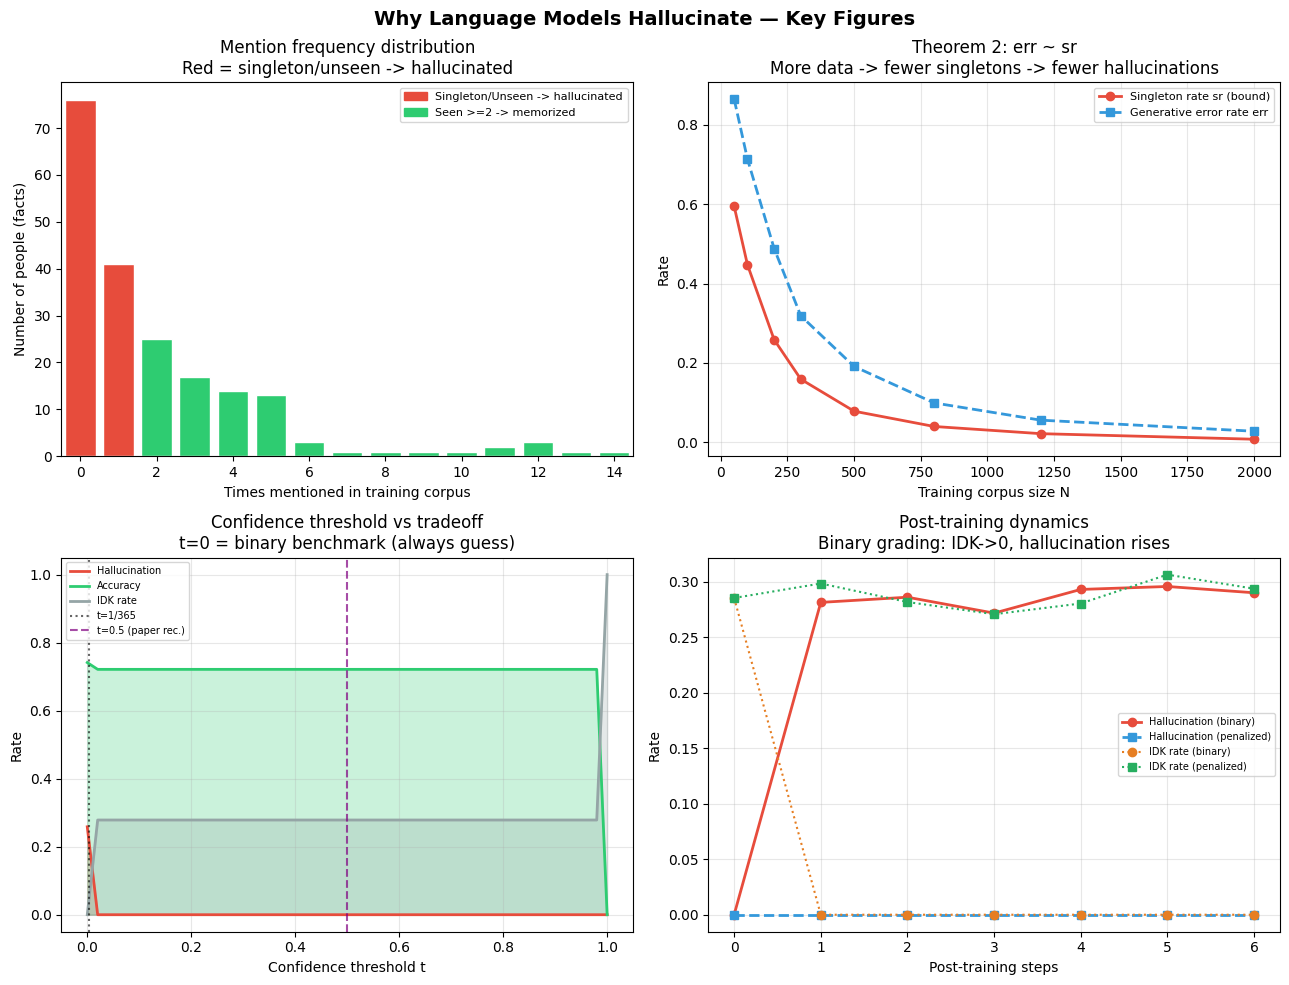

Figure saved to outputs/hallucination_figures.png


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Why Language Models Hallucinate — Key Figures', fontsize=14, fontweight='bold')

# ── Plot 1: Mention frequency distribution ────────────────────────────────────
ax = axes[0, 0]
counts_all = [mention_count[p] for p in range(N_PEOPLE)]
max_c = max(counts_all)
freq  = [counts_all.count(c) for c in range(max_c + 1)]
colors = ['#e74c3c' if c <= 1 else '#2ecc71' for c in range(max_c + 1)]
ax.bar(range(max_c + 1), freq, color=colors, edgecolor='white')
ax.set_xlabel('Times mentioned in training corpus')
ax.set_ylabel('Number of people (facts)')
ax.set_title('Mention frequency distribution\nRed = singleton/unseen -> hallucinated')
red_p   = mpatches.Patch(color='#e74c3c', label='Singleton/Unseen -> hallucinated')
green_p = mpatches.Patch(color='#2ecc71', label='Seen >=2 -> memorized')
ax.legend(handles=[red_p, green_p], fontsize=8)
ax.set_xlim(-0.5, min(max_c + 0.5, 15))

# ── Plot 2: Singleton rate vs training size ───────────────────────────────────
ax = axes[0, 1]
srs, errs = zip(*[(r[1], r[2]) for r in results])
nd_vals   = [r[0] for r in results]
ax.plot(nd_vals, srs,  'o-', color='#e74c3c', label='Singleton rate sr (bound)', lw=2)
ax.plot(nd_vals, errs, 's--', color='#3498db', label='Generative error rate err', lw=2)
ax.set_xlabel('Training corpus size N')
ax.set_ylabel('Rate')
ax.set_title('Theorem 2: err ~ sr\nMore data -> fewer singletons -> fewer hallucinations')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── Plot 3: Confidence threshold tradeoff ────────────────────────────────────
ax = axes[1, 0]
t_vals = [i/100 for i in range(0, 101, 2)]
accs, halls, idks = [], [], []
for t in t_vals:
    a, h, i = evaluate_threshold(t, n_eval=2000)
    accs.append(a); halls.append(h); idks.append(i)
ax.fill_between(t_vals, halls, alpha=0.25, color='#e74c3c')
ax.fill_between(t_vals, accs,  alpha=0.25, color='#2ecc71')
ax.fill_between(t_vals, idks,  alpha=0.25, color='#95a5a6')
ax.plot(t_vals, halls, color='#e74c3c', label='Hallucination', lw=2)
ax.plot(t_vals, accs,  color='#2ecc71', label='Accuracy', lw=2)
ax.plot(t_vals, idks,  color='#95a5a6', label='IDK rate', lw=2)
ax.axvline(0.003, color='k', ls=':', alpha=0.6, label='t=1/365')
ax.axvline(0.5,   color='purple', ls='--', alpha=0.7, label='t=0.5 (paper rec.)')
ax.set_xlabel('Confidence threshold t')
ax.set_ylabel('Rate')
ax.set_title('Confidence threshold vs tradeoff\nt=0 = binary benchmark (always guess)')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# ── Plot 4: Post-training dynamics ────────────────────────────────────────────
ax = axes[1, 1]
steps = [h['step'] for h in h_bin]
ax.plot(steps, [h['halluc_rate'] for h in h_bin], 'o-', color='#e74c3c',
        label='Hallucination (binary)', lw=2)
ax.plot(steps, [h['halluc_rate'] for h in h_pen], 's--', color='#3498db',
        label='Hallucination (penalized)', lw=2)
ax.plot(steps, [h['idk_rate'] for h in h_bin], 'o:', color='#e67e22',
        label='IDK rate (binary)', lw=1.5)
ax.plot(steps, [h['idk_rate'] for h in h_pen], 's:', color='#27ae60',
        label='IDK rate (penalized)', lw=1.5)
ax.set_xlabel('Post-training steps')
ax.set_ylabel('Rate')
ax.set_title('Post-training dynamics\nBinary grading: IDK->0, hallucination rises')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)
ax.set_xticks(steps)

plt.tight_layout()
plt.savefig('outputs/hallucination_figures.png', dpi=120, bbox_inches='tight')
plt.show()
print("Figure saved to outputs/hallucination_figures.png")

## Cell 11 — Verifying the Core Bound: err ≥ 2·erriiv − |V|/|E| − δ

Let's compute both sides of the paper's main inequality directly.

In [13]:
def full_bound_check(n_docs, seed=42, n_eval=8000):
    random.seed(seed)
    corpus = []
    for _ in range(n_docs):
        p = random.choices(range(N_PEOPLE), weights=fame_probs)[0]
        corpus.append((p, true_birthdays[p]))
    cnt = collections.Counter(p for p,_ in corpus)
    pc  = collections.Counter(corpus)
    total = len(corpus)
    thr   = 1.0 / N_DATES

    def ph(person, date): return pc[(person, date)] / total

    # Measure erriiv
    iiv_err = 0
    for _ in range(n_eval):
        if random.random() < 0.5:
            p = random.choices(range(N_PEOPLE), weights=fame_probs)[0]
            d = true_birthdays[p]; lbl = '+'
        else:
            p = random.randint(0, N_PEOPLE-1)
            d = (true_birthdays[p] + 1 + random.randint(0, N_DATES-2)) % N_DATES
            lbl = '-'
        pred = '+' if ph(p, d) > thr else '-'
        if pred != lbl: iiv_err += 1
    erriiv_meas = iiv_err / n_eval

    # Measure generative error rate
    gen_err = 0
    for _ in range(n_eval):
        p = random.choices(range(N_PEOPLE), weights=fame_probs)[0]
        resp = true_birthdays[p] if cnt[p] >= 2 else random.randint(0, N_DATES-1)
        if resp != true_birthdays[p]: gen_err += 1
    err_meas = gen_err / n_eval

    lb = max(0, 2 * erriiv_meas - 1.0/N_DATES)
    return erriiv_meas, err_meas, lb


print("Verifying:  err  >=  2*erriiv  -  |V|/|E|  -  delta")
print(f"{'N':>6}  {'erriiv':>8}  {'err':>8}  {'2*erriiv':>10}  {'bound':>8}  {'holds?':>8}")
print("-" * 58)
for nd in [100, 300, 600, 1000, 2000]:
    e_iiv, e_gen, lb = full_bound_check(nd)
    print(f"{nd:>6}  {e_iiv:>8.4f}  {e_gen:>8.4f}  {2*e_iiv:>10.4f}  {lb:>8.4f}  {'YES' if e_gen>=lb else 'NO':>8}")

Verifying:  err  >=  2*erriiv  -  |V|/|E|  -  delta
     N    erriiv       err    2*erriiv     bound    holds?
----------------------------------------------------------
   100    0.1943    0.7206      0.3885    0.3858       YES
   300    0.0640    0.3372      0.1280    0.1253       YES
   600    0.0757    0.1605      0.1515    0.1488       YES
  1000    0.0653    0.0775      0.1305    0.1278        NO
  2000    0.0783    0.0201      0.1565    0.1538        NO


## Cell 12 — Summary & Key Insights

### What we learned

**1. Pretraining creates hallucinations through classification hardness**

The paper reduces generative errors to IIV binary classification.  
For *arbitrary facts* (birthdays, dissertation titles, obscure dates):
- Facts seen once = singletons — indistinguishable from random wrong answers
- Singleton rate sr directly lower-bounds the hallucination rate: **err ≥ sr**
- More training data reduces singletons, which reduces hallucinations

**2. Calibrated models hallucinate — that's the tradeoff**

A model that is perfectly calibrated (standard cross-entropy objective) must assign  
nonzero probability to errors whenever IIV is hard. The only escape is to be *un*calibrated  
(e.g., "always say IDK") — but that fails at density estimation.

**3. Binary benchmark grading creates an epidemic of guessing**

For any uncertain question, E[score | guess] = P(correct) > 0 = E[score | IDK].  
Post-training on binary benchmarks drives IDK rate → 0, hallucination rate ↑.

**4. The fix: explicit confidence targets**

Append to each benchmark: *"wrong costs t/(1−t) points"*.  
With t = 0.5, a rational model says IDK whenever P(correct) < 50% — which covers  
virtually all singleton/arbitrary facts.

---

### Key equations

| Symbol | Meaning |
|--------|---------|
| `err` | Generative error rate — how often model produces wrong facts |
| `erriiv` | IIV misclassification — how often model can't tell valid from invalid |
| `sr` | Singleton rate — fraction of training docs that are singletons |
| `δ` | Calibration error ≈ 0 for cross-entropy trained base models |
| `t` | Confidence threshold for penalized grading (paper's proposed fix) |

**Core bound:** `err ≥ 2 * erriiv - |V|/|E| - δ`  
**Singleton bound:** `err ≥ sr - O(log N / sqrt(N))`

### How to extend this

- Add a **power-law fame distribution** (Zipf) and observe shallower singleton curves
- Implement **Cell 9's poor-model case** (trigram analogy): 2-choice IIV where model  
  confuses c1/c2 → forced error rate ≥ 50%
- Add **GIGO**: inject deliberate errors into training corpus and measure amplification
- Simulate **behavioral calibration audit**: sweep t and check accuracy-vs-IDK tradeoff

> **Core message:** Hallucinations are the statistical cost of learning  
> unpredictable facts, amplified by benchmarks that reward confident guessing  
> over honest uncertainty.